<a href="https://colab.research.google.com/github/laceywang11/MSSP6070/blob/main/Case_Study_Report_2_Laceyipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **What are the Internet sales of Adventure Works by year for each Country Region?**

In [2]:
import pandas as pd
from google.colab import files
uploaded = files.upload()

Saving InternetSales (1).csv to InternetSales (1).csv


In [3]:
df=pd.read_csv('InternetSales (1).csv', encoding='latin1')
df.head()

/tmp/ipython-input-2106494767.py:1: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('InternetSales (1).csv', encoding='latin1')


,ID,CustomerKey,GeographyKey,City,CountryRegionCode,EnglishCountryRegionName,CustomerAlternateKey,Title,FirstName,MiddleName,...,ProductStandardCost,TotalProductCost,SalesAmount,TaxAmt,Freight,CarrierTrackingNumber,CustomerPONumber,OrderDate,DueDate,ShipDate
0,0,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,1912.1544,1912.1544,3399.99,271.9992,84.9998,NaN,NaN,1/19/2011,1/31/2011,1/26/2011
1,1,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,1265.6195,1265.6195,2319.99,185.5992,57.9998,NaN,NaN,1/18/2013,1/30/2013,1/25/2013
2,2,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,8.2205,8.2205,21.98,1.7584,0.5495,NaN,NaN,1/18/2013,1/30/2013,1/25/2013
3,3,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,1481.9379,1481.9379,2384.07,190.7256,59.6018,NaN,NaN,5/3/2013,5/15/2013,5/10/2013
4,4,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,10.8423,10.8423,28.99,2.3192,0.7248,NaN,NaN,5/3/2013,5/15/2013,5/10/2013


In [4]:
df["OrderDate"] = pd.to_datetime(df["OrderDate"], errors="coerce")
df["Year"] = df["OrderDate"].dt.year
df[["OrderDate", "Year"]].head()

,OrderDate,Year
0,2011-01-19,2011
1,2013-01-18,2013
2,2013-01-18,2013
3,2013-05-03,2013
4,2013-05-03,2013


In [5]:
sales_by_country_year = (
    df.groupby(["EnglishCountryRegionName", "Year"])["SalesAmount"]
      .sum()
      .reset_index()
      .sort_values(["EnglishCountryRegionName", "Year"])
)
sales_by_country_year.head()

,EnglishCountryRegionName,Year,SalesAmount
0,Australia,2010,2.090978e+04
1,Australia,2011,2.563732e+06
2,Australia,2012,2.128407e+06
3,Australia,2013,4.339443e+06
4,Australia,2014,8.507720e+03


In [6]:
import matplotlib.pyplot as plt
year_totals = (
    df.groupby("Year")["SalesAmount"]
      .sum()
      .sort_index()
)
year_totals

,SalesAmount
Year,
2010,4.342104e+04
2011,7.075526e+06
2012,5.842485e+06
2013,1.635155e+07
2014,4.569472e+04


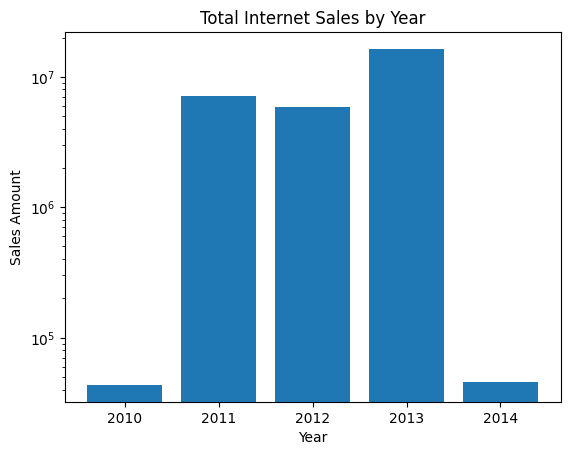

In [7]:
#Visualization of Total Internet Sale by Year--Bar Chart
plt.bar(year_totals.index.astype(int), year_totals.values)
plt.title("Total Internet Sales by Year")
plt.xlabel("Year")
plt.ylabel("Sales Amount")
plt.yscale("log")
plt.show()

In [8]:
sales_table = sales_by_country_year.pivot(
    index="Year",
    columns="EnglishCountryRegionName",
    values="SalesAmount"
)
sales_table.head()

EnglishCountryRegionName,Australia,Canada,France,Germany,United Kingdom,United States
Year,,,,,,
2010,2.090978e+04,3.578270e+03,3.399990e+03,NaN,6.990982e+02,1.483390e+04
2011,2.563732e+06,5.715718e+05,4.108453e+05,5.205002e+05,5.505912e+05,2.458285e+06
2012,2.128407e+06,3.076045e+05,6.480655e+05,6.086580e+05,7.127010e+05,1.437049e+06
2013,4.339443e+06,1.085633e+06,1.578512e+06,1.761876e+06,2.124007e+06,5.462079e+06
2014,8.507720e+03,9.457620e+03,3.195060e+03,3.277830e+03,3.713640e+03,1.754285e+04


In [9]:
sum = sales_table.sum().sort_values(ascending=False)
sum

,0
EnglishCountryRegionName,
United States,9.389790e+06
Australia,9.061001e+06
United Kingdom,3.391712e+06
Germany,2.894312e+06
France,2.644018e+06
Canada,1.977845e+06


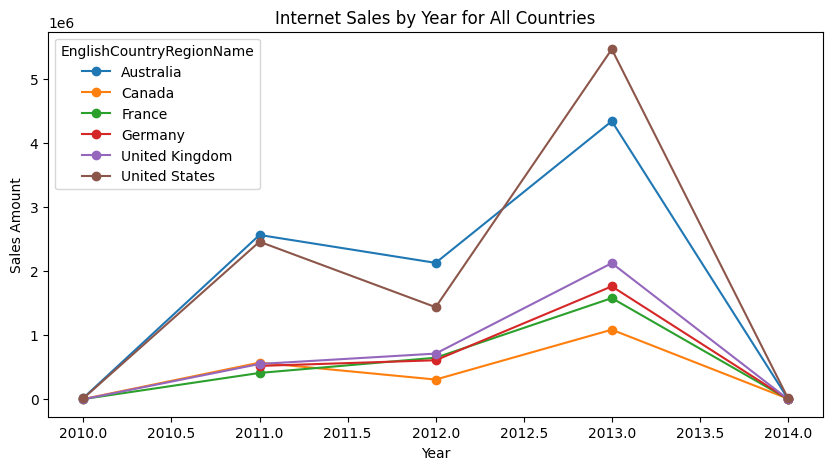

In [10]:
#Visualization of Internet sales by Yea for All Countries
sales_table.plot(marker="o", figsize=(10,5))
plt.title("Internet Sales by Year for All Countries")
plt.xlabel("Year")
plt.ylabel("Sales Amount")
plt.show()

# **Generate summary statistics including min, max, and standard deviation for Yearly Income, Gender by Country Regions.**

In [11]:
df["YearlyIncome"] = pd.to_numeric(df["YearlyIncome"], errors="coerce")
df.groupby(["EnglishCountryRegionName", "Gender"])["YearlyIncome"].agg(["min", "max", "std","mean"])

min     max           std          mean
EnglishCountryRegionName Gender                                           
Australia                F       10000  160000  30613.956169  67060.583396
                         M       10000  170000  32550.778171  65412.912913
Canada                   F       10000  170000  19435.158438  58651.315789
                         M       10000  170000  22702.851581  61460.221551
France                   F       10000  110000  28421.836245  39367.134124
                         M       10000  110000  28665.660622  39805.545553
Germany                  F       10000  130000  37622.814569  48287.234043
                         M       10000  130000  37487.619366  46730.837790
United Kingdom           F       10000  170000  51130.689140  56518.670979
                         M       10000  170000  50963.707551  55771.754636
United States            F       10000  170000  25498.805483  64766.897585
                         M       10000  170000  26520.348175  65450.196961

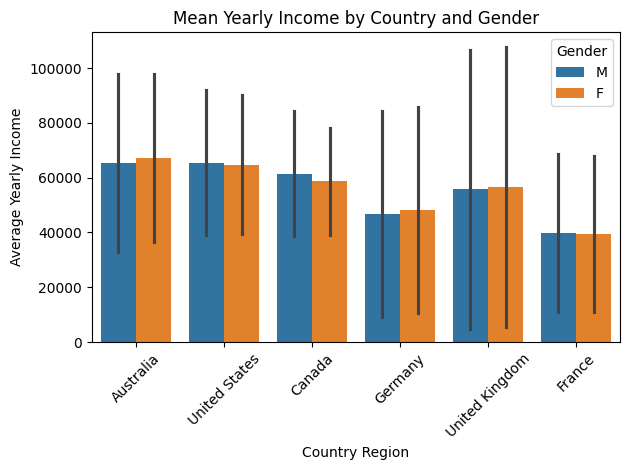

In [12]:
#Visualization for Mean Yearly Income by Country and Gender
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(
    data=df,
    x="EnglishCountryRegionName",
    y="YearlyIncome",
    hue="Gender",
    estimator="mean",
    errorbar="sd"
)
plt.title("Mean Yearly Income by Country and Gender")
plt.xlabel("Country Region")
plt.ylabel("Average Yearly Income")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **What is the average price of the product category that generates the most sales?**

In [13]:
df["SalesAmount"] = pd.to_numeric(df["SalesAmount"], errors="coerce")
df["UnitPrice"]   = pd.to_numeric(df["UnitPrice"], errors="coerce")

In [14]:
def make_category(name):
    name = str(name).lower()
    if "mountain" in name or "road" in name or "touring" in name:
        return "Bikes"
    elif "helmet" in name or "bottle" in name or "cage" in name or "cap" in name or "fender" in name:
        return "Accessories"
    elif "tire" in name or "tube" in name or "chain" in name or "brake" in name or "saddle" in name:
        return "Components"
    elif "jersey" in name or "short" in name or "glove" in name or "socks" in name or "vest" in name:
        return "Clothing"
    else:
        return "Other"

In [15]:
df["Category"] = df["EnglishProductName"].apply(make_category)
df.head()

,ID,CustomerKey,GeographyKey,City,CountryRegionCode,EnglishCountryRegionName,CustomerAlternateKey,Title,FirstName,MiddleName,...,SalesAmount,TaxAmt,Freight,CarrierTrackingNumber,CustomerPONumber,OrderDate,DueDate,ShipDate,Year,Category
0,0,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,3399.99,271.9992,84.9998,NaN,NaN,2011-01-19,1/31/2011,1/26/2011,2011,Bikes
1,1,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,2319.99,185.5992,57.9998,NaN,NaN,2013-01-18,1/30/2013,1/25/2013,2013,Bikes
2,2,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,21.98,1.7584,0.5495,NaN,NaN,2013-01-18,1/30/2013,1/25/2013,2013,Bikes
3,3,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,2384.07,190.7256,59.6018,NaN,NaN,2013-05-03,5/15/2013,5/10/2013,2013,Bikes
4,4,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,28.99,2.3192,0.7248,NaN,NaN,2013-05-03,5/15/2013,5/10/2013,2013,Bikes


In [16]:
category_sales = df.groupby("Category")["SalesAmount"].sum().sort_values(ascending=False)
category_sales

,SalesAmount
Category,
Bikes,2.870993e+07
Accessories,2.662013e+05
Clothing,2.487647e+05
Other,1.337847e+05


In [17]:
top_category = category_sales.index[0]
avg_price = df[df["Category"] == "Bikes"]["UnitPrice"].mean()
print(top_category)
print(avg_price)

Bikes
792.5883168346078


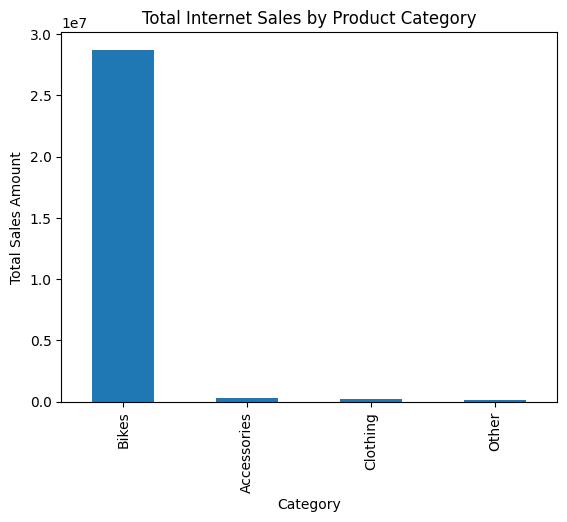

In [18]:
#Visualization for Category_Sales
category_sales.plot(kind="bar")
plt.title("Total Internet Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales Amount")
plt.show()

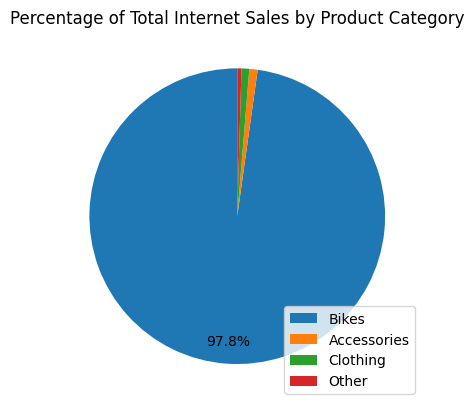

In [34]:
category_sales_percent = category_sales / category_sales.sum() * 100
category_sales_percent.plot(
    kind="pie",
    y="SalesAmount",
    startangle=90,
    legend=True,
    labels=None,
    pctdistance=0.85,
    autopct=lambda p: f'{p:.1f}%' if p > 1 else '',
    ylabel="")
plt.title("Percentage of Total Internet Sales by Product Category")
plt.show()

# **Does owning a home make a difference in sales? Explain your analysis.**

In [19]:
summary = (
    df.groupby("HouseOwnerFlag")["SalesAmount"]
      .agg(count="count", mean="mean", median="median", total="sum")
      .round(2)
)
summary

,count,mean,median,total
HouseOwnerFlag,,,,
0,18699,479.88,29.99,8973327.42
1,41699,488.87,32.60,20385349.80


In [20]:
mean_owner = summary.loc[1, "mean"]
mean_nonowner = summary.loc[0, "mean"]
diff = mean_owner - mean_nonowner
pct = diff / mean_nonowner * 100
print(f"Homeowners spend ${diff:.2f} more than non-homeowners ({pct:.1f}% higher).")

Homeowners spend $8.99 more than non-homeowners (1.9% higher).


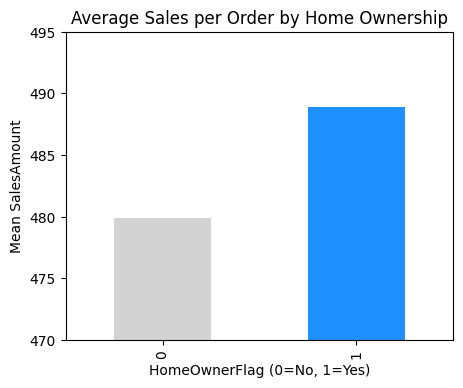

In [21]:
#Visualization for HomeOwner vs Non-HomeOwner
ax = summary["mean"].plot(kind="bar", color=["lightgray", "dodgerblue"], figsize=(5,4))
plt.title("Average Sales per Order by Home Ownership")
plt.xlabel("HomeOwnerFlag (0=No, 1=Yes)")
plt.ylabel("Mean SalesAmount")

plt.ylim(470, 495)
plt.show()